# 7.  Write a program for sharpening an image using unsharp masking. 

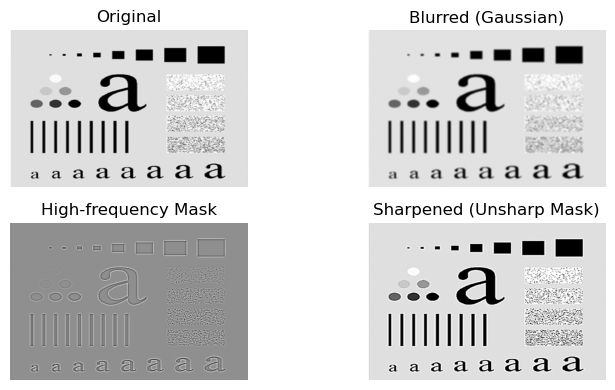

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def read_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Cannot read image at {path}")
    return img

# def unsharp_masking(image, blur_kernel_size=(5, 5), amount=1.5):
#     blurred = cv2.GaussianBlur(image, blur_kernel_size, 0)

#     mask = cv2.subtract(image, blurred)

#     sharpened = cv2.addWeighted(image, 1.0 + amount, blurred, -amount, 0)

#     return blurred, mask, sharpened
def gaussian_kernel(size, sigma):
    """Generate a Gaussian kernel."""
    ax = np.linspace(-(size // 2), size // 2, size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / np.sum(kernel)

def convolve(image, kernel):
    """Convolve an image with the provided kernel."""
    kH, kW = kernel.shape
    pad_y, pad_x = kH // 2, kW // 2
    padded_img = np.pad(image, ((pad_y, pad_y), (pad_x, pad_x)), mode='edge')
    output = np.zeros_like(image, dtype=np.float32)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded_img[i:i+kH, j:j+kW]
            output[i, j] = np.sum(region * kernel)

    return output

def unsharp_masking(image, blur_kernel_size=(5, 5), amount=1.5):
    kernel = gaussian_kernel(blur_kernel_size[0], sigma=2)
    
    blurred = convolve(image, kernel)
    blurred = np.clip(blurred, 0, 255).astype(np.uint8)

    mask = np.subtract(image.astype(np.int16), blurred.astype(np.int16))
    mask = np.clip(mask, -255, 255).astype(np.int16)

    sharpened = np.add(image.astype(np.int16), amount * mask)
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

    return blurred, mask, sharpened


def plot_unsharp_results(original, blurred, mask, sharpened):
    plt.figure(figsize=(8, 4))

    plt.subplot(2, 2, 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(blurred, cmap='gray')
    plt.title("Blurred (Gaussian)")
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(mask, cmap='gray')
    plt.title("High-frequency Mask")
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(sharpened, cmap='gray')
    plt.title("Sharpened (Unsharp Mask)")
    plt.axis('off')

    plt.tight_layout()
    plt.savefig("outimg_problem7.png")
    plt.show()

def main():
    image_path = "../test_imgs/test_img.png"  
    image = read_image(image_path)

    blurred, mask, sharpened = unsharp_masking(image)
    plot_unsharp_results(image, blurred, mask, sharpened)

if __name__ == "__main__":
    main()
